<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_1lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №1

"КЛАСИФІКАЦІЯ НОВИН НА ОСНОВІ ЛОГІСТИЧНОЇ РЕГРЕСІЇ PYTORCH"

Імпорт бібліотек

In [1]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from collections import defaultdict
from scipy.sparse import csr_matrix
from torch.utils.data import Dataset, DataLoader
import copy

Завантаження даних

In [2]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

Покращена токенізація з базовими стоп-словами

In [3]:
stop_words = {'that', 'this', 'with', 'from', 'your', 'have', 'they', 'will', 'would', 'there', 'their', 'what', 'about', 'which', 'when'}

def tokenize_text_simple(text, min_token_length=4):
    tokens = re.findall(r'\b[a-zA-Z0-9]{4,}\b', text.lower())
    return [token for token in tokens if len(token) >= min_token_length and token not in stop_words]

def tokenize_corpus(corpus):
    return [tokenize_text_simple(text) for text in corpus]

tokenized_train = tokenize_corpus(newsgroups_train.data)
tokenized_test = tokenize_corpus(newsgroups_test.data)

Побудова словника

In [4]:
def build_vocabulary(tokenized_texts, min_freq=5, max_doc_freq=0.8, max_vocab_size=20000):
    token_counts = defaultdict(int)
    num_docs = len(tokenized_texts)
    for tokens in tokenized_texts:
        unique_tokens = set(tokens)
        for token in unique_tokens:
            token_counts[token] += 1

    filtered_tokens = {
        token: count for token, count in token_counts.items()
        if count >= min_freq and count / num_docs <= max_doc_freq
    }

    sorted_tokens = sorted(filtered_tokens.items(), key=lambda x: x[1], reverse=True)[:max_vocab_size]

    word_to_id = {"<UNK>": 0}
    for idx, (token, _) in enumerate(sorted_tokens, start=1):
        word_to_id[token] = idx

    word_to_frequency = [filtered_tokens.get(token, 0) / num_docs for token in word_to_id]
    return word_to_id, word_to_frequency

word_to_id, word_to_frequency = build_vocabulary(tokenized_train)

Векторизація

In [5]:
def vectorize_texts(tokenized_texts, word_to_id, word_to_frequency, mode='TF-IDF', scale=True):
    num_texts = len(tokenized_texts)
    vocab_size = len(word_to_id)
    data, rows, cols = [], [], []

    for i, tokens in enumerate(tokenized_texts):
        for token in tokens:
            if token in word_to_id:
                token_id = word_to_id[token]
                data.append(1)
                rows.append(i)
                cols.append(token_id)

    freq_matrix = csr_matrix((data, (rows, cols)), shape=(num_texts, vocab_size))

    if mode == 'TF':
        row_sums = np.array(freq_matrix.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1
        freq_matrix = freq_matrix.multiply(1 / row_sums[:, None])
    elif mode == 'IDF':
        idf = np.log((num_texts + 1) / (1 + freq_matrix.sum(axis=0))) + 1
        freq_matrix = freq_matrix.multiply(idf)
    elif mode == 'TF-IDF':
        row_sums = np.array(freq_matrix.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1
        freq_matrix = freq_matrix.multiply(1 / row_sums[:, None])
        col_sums = np.array(freq_matrix.sum(axis=0)).flatten()
        col_sums[col_sums == 0] = 1
        idf = np.log((num_texts + 1) / (col_sums + 1)) + 1
        freq_matrix = freq_matrix.multiply(idf)

    if scale:
        max_val = freq_matrix.max()
        if max_val > 0:
            freq_matrix = freq_matrix.multiply(1 / max_val)

    return freq_matrix

feature_matrix_train = vectorize_texts(tokenized_train, word_to_id, word_to_frequency, mode='TF-IDF')
feature_matrix_test = vectorize_texts(tokenized_test, word_to_id, word_to_frequency, mode='TF-IDF')

Dataset та Модель

In [9]:
class SparseFeaturesDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features.tocsr()
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        feature = torch.tensor(self.features[idx].toarray().squeeze(), dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return feature, label

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)
    def forward(self, x):
        return self.linear(x)

Цикл навчання з валідацією та збереженням кращої моделі

In [10]:
def train_eval_loop(model, train_dataset, val_dataset, criterion, optimizer, epochs, batch_size, device):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    model.to(device)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == batch_y).sum().item()

        # Валідація
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == batch_y).sum().item()

        t_loss = train_loss / len(train_loader)
        v_loss = val_loss / len(val_loader)
        t_acc = train_correct / len(train_dataset)
        v_acc = val_correct / len(val_dataset)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # 4. Збереження кращої моделі
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_model.pth")

    print("Модель збережена! Найкращий Val Loss:", best_val_loss)
    return history

labels_train = newsgroups_train.target
labels_test = newsgroups_test.target

train_dataset = SparseFeaturesDataset(feature_matrix_train, labels_train)
val_dataset = SparseFeaturesDataset(feature_matrix_test, labels_test)

input_dim = feature_matrix_train.shape[1]
output_dim = len(set(labels_train))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LogisticRegressionModel(input_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

history = train_eval_loop(model, train_dataset, val_dataset, criterion, optimizer, epochs=20, batch_size=64, device=device)

Модель збережена! Найкращий Val Loss: 1.4425394110760446


2. Графіки втрат (Train/Validation)

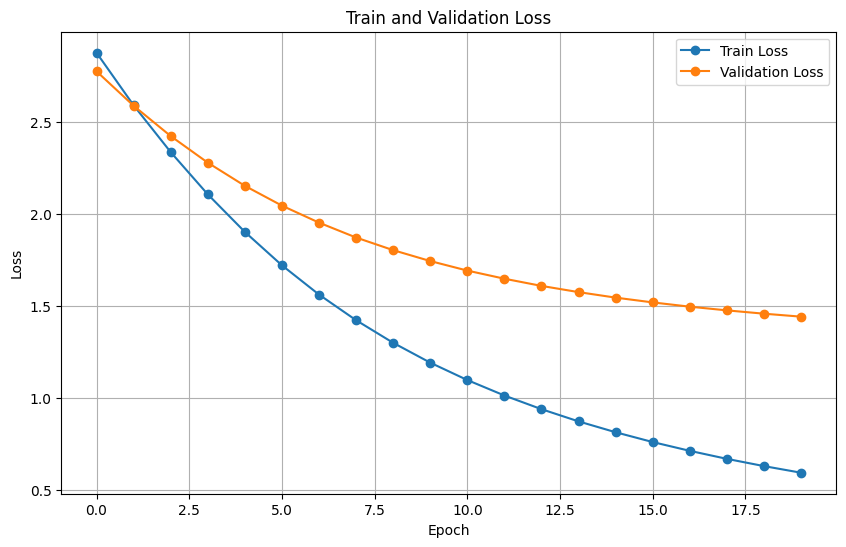

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Train and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Графік демонструє стабільне зниження функції втрат на тренувальній (синя лінія) та валідаційній (помаранчева лінія) вибірках протягом 20 епох. Тренувальні втрати зменшуються швидше і досягають нижчого значення (близько 0.6), тоді як валідаційні втрати знижуються повільніше, наближаючись до плато на рівні близько 1.4. Явних ознак перенавчання (зростання валідаційних втрат) на цьому етапі немає, модель успішно навчається.

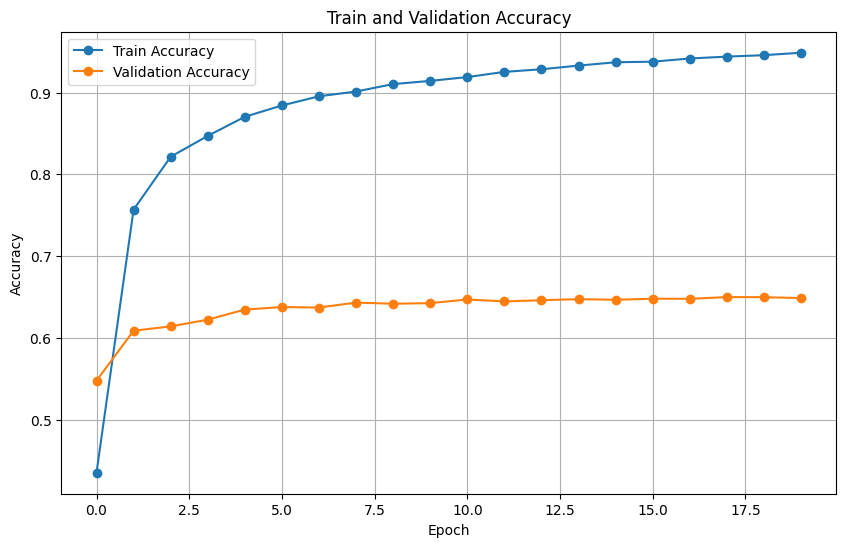

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Train and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


Графік демонструє зміну точності на тренувальній (синя лінія) та валідаційній (помаранчева лінія) вибірках протягом 20 епох. Тренувальна точність постійно зростає, досягаючи приблизно 0.95. Валідаційна точність швидко виходить на плато на рівні близько 0.65 і припиняє зростати. Велика різниця між цими показниками та зупинка росту валідаційної точності свідчать про перенавчання (overfitting) моделі.

In [13]:
loaded_model = LogisticRegressionModel(input_dim, output_dim)
loaded_model.load_state_dict(torch.load("best_model.pth"))
loaded_model.eval()
print("Модель успішно завантажена!")

Модель успішно завантажена!


In [14]:
modes = ['bin', 'TF', 'IDF', 'TF-IDF']
results = {}

for mode in modes:
    print(f"\nНавчання для режиму: {mode}")
    fm_train = vectorize_texts(tokenized_train, word_to_id, word_to_frequency, mode=mode)
    fm_test = vectorize_texts(tokenized_test, word_to_id, word_to_frequency, mode=mode)

    ds_train = SparseFeaturesDataset(fm_train, labels_train)
    ds_test = SparseFeaturesDataset(fm_test, labels_test)

    test_model = LogisticRegressionModel(input_dim, output_dim)
    test_optimizer = optim.Adam(test_model.parameters(), lr=0.01)

    mode_history = train_eval_loop(test_model, ds_train, ds_test, criterion, test_optimizer, epochs=10, batch_size=64, device=device)
    results[mode] = mode_history['val_acc'][-1]

print("\nФінальні результати точності на валідації:")
for mode, acc in results.items():
    print(f"{mode}: {acc:.4f}")


Навчання для режиму: bin
Модель збережена! Найкращий Val Loss: 2.502335520113929

Навчання для режиму: TF
Модель збережена! Найкращий Val Loss: 1.7328014090909796

Навчання для режиму: IDF
Модель збережена! Найкращий Val Loss: 2.4060433092763867

Навчання для режиму: TF-IDF
Модель збережена! Найкращий Val Loss: 1.7436159869371834

Фінальні результати точності на валідації:
bin: 0.5526
TF: 0.6393
IDF: 0.5884
TF-IDF: 0.6423


Найкращу якість класифікації забезпечує векторизація TF-IDF (точність 0.6423).
TF-IDF є найбільш збалансованим підходом, що враховує і частотність слова у тексті, і його важливість у корпусі. Цей метод найкраще підходить для тематичної класифікації.

Висновок

У ході виконання роботи було успішно реалізовано модель машинного навчання на базі логістичної регресії з використанням бібліотеки PyTorch для задачі багатокласової класифікації новинних текстів набору даних "20 Newsgroups". Було налаштовано повний цикл підготовки даних, що включав токенізацію, очищення, побудову словника та ефективне представлення текстів у вигляді розріджених матриць ознак. Організовано цикл навчання та валідації моделі зі збереженням її найкращих параметрів. Практичне порівняння методів зважування ознак (bin, TF, IDF, TF-IDF) підтвердило, що векторизація TF-IDF забезпечує найвищу якість класифікації (точність 0.6423), оскільки цей метод є найбільш збалансованим і враховує як локальну частотність слова, так і його глобальну значущість у межах усього корпусу.

Контрольні питання

*1.	Що	таке	метод	"мішка	слів"	і	як	він	використовується	для представлення текстів?*

Метод "мішка слів" — це підхід для перетворення тексту у числовий вектор на основі частоти появи слів зі словника, при якому ігнорується порядок слів та граматика.

*2.	Яка роль TF, IDF і TF-IDF у методі "мішка слів"?*

TF визначає частоту слова в конкретному тексті, IDF оцінює важливість слова для всього корпусу текстів, а TF-IDF об'єднує ці метрики для збалансованого зважування токенів.

*3.	Що таке токенізація і чому вона важлива на етапі передобробки?*

Токенізація — це процес розбиття тексту на базові лексичні елементи (токени); вона потрібна для подальшого перетворення тексту з неструктурованого формату у числовий.

*4.	Для чого використовується побудова словника під час аналізу тексту?*

Побудова словника використовується для відображення кожного унікального слова у його числовий індекс, що є обов'язковим для представлення тексту у вигляді числових векторів.

*5.	Які переваги мають розріджені матриці у роботі з текстовими даними?*

Розріджені матриці зберігають лише ненульові значення, що забезпечує суттєве зменшення обсягу використовуваної пам’яті та прискорення виконання обчислень алгоритмами машинного навчання.

*6.	Що таке логістична регресія і чому вона ефективна для класифікації текстів?*

Логістична регресія — це модель, яка передбачає ймовірність належності тексту до класу за допомогою логістичної функції (сигмоїди); вона ефективна, оскільки масштабується для розріджених даних та прямо враховує ваги ознак (TF-IDF).

*7.	Як у PyTorch реалізувати цикл навчання моделі з валідацією?*

Потрібно ітерувати по епохах, виконуючи на тренувальних даних прямий прохід, обчислення втрат, зворотне поширення та оновлення ваг оптимізатором, після чого перевести модель у режим оцінки (model.eval()) і без обчислення градієнтів (torch.no_grad()) підрахувати метрики на валідаційному наборі даних.

*8.	Які ключові переваги PyTorch Dataset під час роботи з текстовими даними?*

PyTorch Dataset інкапсулює дані, дозволяє ефективно зберігати ознаки у розрідженому форматі (конвертуючи у щільний формат лише запитані батчі) та забезпечує пряму інтеграцію з DataLoader.

*9.	Чому важливо проводити валідацію моделі під час навчання?*

Валідація необхідна для оцінки якості роботи моделі на нових даних та для виявлення перенавчання.

*10.	Як зберегти найкращу модель у PyTorch та завантажити її для подальшого використання?*

Збереження: виклик torch.save(model.state_dict(), "best_model.pth"). Завантаження: ініціалізація моделі, виклик loaded_model.load_state_dict(torch.load("best_model.pth")), а потім переведення в режим оцінки за допомогою loaded_model.eval().